# Blended Backdoor Attack — VGG-16 (GTSRB)

**Threat model: data-poisoning / supply-chain** (untrusted pretrained models or tampered datasets). An attacker who injects a small fraction of poisoned samples installs a hidden backdoor: the model behaves normally on clean inputs but flips to a chosen target class whenever the trigger is present.

**Trigger = Blended (Chen et al. 2017):** a fixed, seeded, **whole-image random-noise pattern** convex-blended into the image at opacity `alpha` (`x' = (1-a)x + a*k`). This is the *global* counterpart to the *localized* BadNets 24px patch (Gu et al. 2017) — the two together give the benchmark both a localized and a global backdoor.

This is a **training-time** threat, distinct from the evasion attacks (FGSM/PGD/AutoAttack). **Scope: Blended only, attacks-only (defenses are future work).**

**The two metrics:**
- **Clean Accuracy (CA)** — accuracy on the un-triggered test set (measures *stealth* of the backdoor's effect on benign behavior).
- **Attack Success Rate (ASR)** — fraction of *triggered* test images (of non-target classes) classified as the target class. At 0% poisoning ASR should be near-chance — the control proving the trigger only works *because of poisoning*.

## Experimental scope — v1
**v1 (current): two INDEPENDENT 1-D sweeps** — Block A varies poison rate at fixed alpha; Block B varies alpha at fixed poison rate. These locate each floor separately but assume the two axes don't interact. **v2 (future): a full 2-D alpha × poison-rate grid (ASR heatmap)** to capture interaction and find joint (rate, alpha) operating points — the two 1-D sweeps cannot establish joint optima. **Block C (below)** implements a focused version of this: a small 2-D grid over just the floor corner where ASR actually varies.

## Configuration & imports

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torchvision.models import VGG16_Weights
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
import numpy as np
from PIL import Image
import os, json, random
import matplotlib.pyplot as plt

# ── Blended configuration (cell 0) ──────────────────────────────────────
NUM_CLASSES   = 43
TARGET_LABEL  = 0            # all-to-one: triggered images -> class 0 (configurable)
POISON_RATES  = [0.0, 0.0001, 0.00025, 0.0005, 0.001, 0.0025, 0.005, 0.01, 0.05, 0.10, 0.20]   # EXACT BadNets grid (A-vs-BadNets comparability)

IMG_SIZE      = 224
TRIGGER_SEED  = 1234         # FIXED FOREVER — defines the trigger pattern. NOT a swept
                             # variable; one fixed key across every model/rate/alpha/seed.
BLEND_ALPHA          = 0.2   # fixed alpha for Block A's rate sweep. 0.2 is Chen et al.'s
                             # value for the RANDOM-noise pattern and the modern GTSRB-
                             # backdoor-lit standard; high enough that opacity is not the
                             # bottleneck so poison RATE is the only variable.
BLEND_ALPHAS         = [0.0025, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]   # Block B alpha
                             # grid, extended DOWN to find the ASR floor (ASR already saturated
                             # ~98% by 0.02, so the floor is below it). Spans near-invisible
                             # (0.0025) -> Chen Hello-Kitty (0.02) -> random-noise (0.2) ->
                             # clearly visible (0.3).
RATE_FOR_ALPHA_SWEEP = 0.05  # fixed 5% poison for Block B — safely above the BadNets
                             # reliability floor so poison count is not the bottleneck and
                             # alpha is the only variable.

SEED          = 42
SEEDS         = [42, 123, 7]    # multi-seed averaging for the noisy low-rate floor
LOW_RATE_THRESHOLD = 0.005      # rates <= this are noisy (few poisoned imgs) -> run once per
                                # seed; which images get picked matters, so we average. Higher
                                # rates (and rate 0 control) run single-seed with seed 42 only.

MODEL_NAME  = 'vgg16'
MODEL_TITLE = 'VGG-16'
DS_TITLE    = 'GTSRB'
DS_SHORT    = 'gtsrb'
CKPT_TAG    = ''   # checkpoint name infix ('' for gtsrb, '_bel' for bel)
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
MODELS_DIR  = 'models'   # all trained checkpoints (.pth) are saved here

DATA_DIR   = 'dataset'
TRAIN_DIR  = os.path.join(DATA_DIR, 'Train')
TEST_CSV   = os.path.join(DATA_DIR, 'Test.csv')
TEST_DIR   = DATA_DIR
VAL_SPLIT  = 0.2

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
print(f'{MODEL_TITLE} | {DS_TITLE} | classes={NUM_CLASSES} | epochs={NUM_EPOCHS} | batch={BATCH_SIZE}')
print(f'Blended: alpha_A={BLEND_ALPHA}, alpha grid={BLEND_ALPHAS}, rate_B={RATE_FOR_ALPHA_SWEEP}, trigger_seed={TRIGGER_SEED}')
os.makedirs(MODELS_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Using device: cuda
VGG-16 | GTSRB | classes=43 | epochs=20 | batch=32
Blended: alpha_A=0.2, alpha grid=[0.0025, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3], rate_B=0.05, trigger_seed=1234


## Transforms — split so the trigger lives in pixel `[0,1]` space
Same augmentation/resize as the clean training notebook, but the final `Normalize` is **factored out**. The dataset wrappers produce a `[0,1]` tensor, blend the trigger there (Chen et al. blend in pixel space), and normalize **last**.

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Final normalization, applied AFTER the trigger is blended (see Part 1/2).
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

# [0,1]-space transforms: identical to the clean notebook MINUS the trailing Normalize.
train_transform_01 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
])
val_test_transform_01 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# De-normalize helper (for visualization / metrics that need [0,1]).
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)
print('Transforms defined (trigger blended in [0,1] pixel space, normalize applied last).')

Transforms defined (trigger blended in [0,1] pixel space, normalize applied last).


## Datasets — reused `NumericImageFolder` / `GTSRBTestDataset`
Same correct integer label mapping (`'10' -> 10`, matching `Test.csv` ClassId) and same 80/20 train/val split (seed=42) as the clean training notebook. The only change: these carry the **`[0,1]`-space** transforms (normalize is added later by the wrappers).

In [3]:
class NumericImageFolder(torchvision.datasets.ImageFolder):
    """ImageFolder that sorts class folders by integer value, not alphabetically.
    Default alphabetical sort maps folder '10' -> index 2 instead of 10,
    which misaligns with the integer ClassId values in Test.csv."""
    def find_classes(self, directory):
        classes = sorted(os.listdir(directory), key=lambda x: int(x))
        class_to_idx = {cls: int(cls) for cls in classes}
        return classes, class_to_idx


class GTSRBTestDataset(Dataset):
    def __init__(self, csv_path, root_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['Path'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['ClassId'])
        if self.transform:
            image = self.transform(image)
        return image, label

full_train_dataset = NumericImageFolder(TRAIN_DIR, transform=train_transform_01)
assert full_train_dataset.class_to_idx['10'] == 10, 'Label mapping is wrong!'
print(f"Label mapping check passed: class '10' -> index {full_train_dataset.class_to_idx['10']}")

n_total = len(full_train_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val
train_split, val_split = random_split(
    full_train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
# Val split uses the no-augmentation [0,1] transform (deterministic, like the clean notebook).
val_split.dataset = NumericImageFolder(TRAIN_DIR, transform=val_test_transform_01)
test_split = GTSRBTestDataset(TEST_CSV, TEST_DIR, transform=val_test_transform_01)

print(f'Train: {n_train} | Val: {n_val} | Test: {len(test_split)}')
print('NOTE: poison rates are applied to the {} training images (the 80% split that is '
      'actually trained on), matching the clean notebooks. The val split stays clean for '
      'honest checkpoint selection.'.format(n_train))

# Zero-poison-image guard (BOTH datasets): at the lowest rates round(rate*n_train) can be 0
# (especially on the small bel train set, ~3660 imgs). A rate>0 that poisons 0 images is
# identical to the clean control and would waste seed-runs, so we drop it here. The control
# (rate 0) is always kept. ACTIVE_RATES is what Block A iterates over.
def n_poison_for(rate):
    return int(round(rate * n_train))

ACTIVE_RATES = []
print(f'\nPoison-rate plan (n_train={n_train}):')
for r in POISON_RATES:
    npois = n_poison_for(r)
    if r > 0 and npois == 0:
        print(f'  SKIP  p={r*100:.4g}% -> {npois} poisoned imgs (rounds to 0; identical to control)')
        continue
    print(f'  keep  p={r*100:.4g}% -> {npois} poisoned imgs')
    ACTIVE_RATES.append(r)
print(f'Block B fixed rate {RATE_FOR_ALPHA_SWEEP*100:.4g}% -> {n_poison_for(RATE_FOR_ALPHA_SWEEP)} poisoned imgs')

Label mapping check passed: class '10' -> index 10
Train: 31368 | Val: 7841 | Test: 12630
NOTE: poison rates are applied to the 31368 training images (the 80% split that is actually trained on), matching the clean notebooks. The val split stays clean for honest checkpoint selection.

Poison-rate plan (n_train=31368):
  keep  p=0% -> 0 poisoned imgs
  keep  p=0.01% -> 3 poisoned imgs
  keep  p=0.025% -> 8 poisoned imgs
  keep  p=0.05% -> 16 poisoned imgs
  keep  p=0.1% -> 31 poisoned imgs
  keep  p=0.25% -> 78 poisoned imgs
  keep  p=0.5% -> 157 poisoned imgs
  keep  p=1% -> 314 poisoned imgs
  keep  p=5% -> 1568 poisoned imgs
  keep  p=10% -> 3137 poisoned imgs
  keep  p=20% -> 6274 poisoned imgs
Block B fixed rate 5% -> 1568 poisoned imgs


## Part 1 — Trigger function (the Blended pattern)
Chen et al. 2017: a **fixed, seeded, full-image random-noise** pattern `k`, convex-blended into the image at opacity `alpha`: `x' = (1-alpha)*x + alpha*k`, in `[0,1]` pixel space **before** normalization. `TRIGGER_SEED` is fixed forever — one trigger key shared across every model / rate / alpha / seed; it is **not** a swept variable. `alpha` *is* swept (Block B). Both operands are in `[0,1]` so the blend stays in `[0,1]` — no clamp needed.

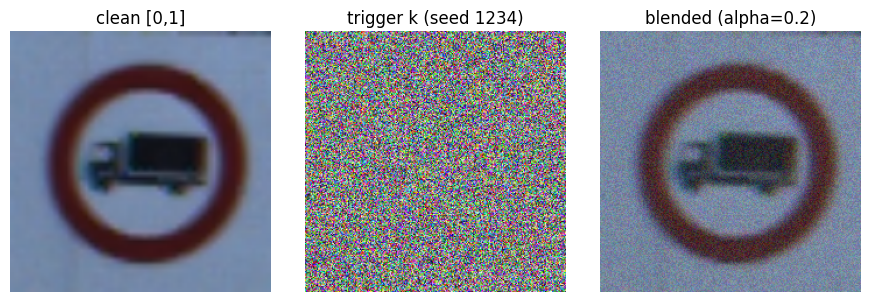

apply_trigger ready — whole-image blend in [0,1] pixel space, normalize applied afterward.


In [4]:
# Fixed, seeded whole-image trigger pattern k (Chen et al. 2017). Defined ONCE from
# TRIGGER_SEED — identical across every model/rate/alpha/seed.
_tg = torch.Generator().manual_seed(TRIGGER_SEED)
TRIGGER_PATTERN = torch.rand(3, IMG_SIZE, IMG_SIZE, generator=_tg)   # [0,1] CHW, fixed

def apply_trigger(img, alpha):
    # Convex blend in [0,1] space BEFORE normalize (Chen et al.: x' = (1-a)x + a*k).
    # Both operands in [0,1] so output is in [0,1] — no clamp needed.
    return (1.0 - alpha) * img + alpha * TRIGGER_PATTERN

# Quick preview at the Block-A alpha.
_img0, _ = test_split[0]
_trig0 = apply_trigger(_img0, BLEND_ALPHA)
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(_img0.permute(1, 2, 0).numpy());          ax[0].set_title('clean [0,1]'); ax[0].axis('off')
ax[1].imshow(TRIGGER_PATTERN.permute(1, 2, 0).numpy()); ax[1].set_title(f'trigger k (seed {TRIGGER_SEED})'); ax[1].axis('off')
ax[2].imshow(_trig0.permute(1, 2, 0).numpy());          ax[2].set_title(f'blended (alpha={BLEND_ALPHA})'); ax[2].axis('off')
plt.tight_layout(); plt.show()
print('apply_trigger ready — whole-image blend in [0,1] pixel space, normalize applied afterward.')

## Part 2 — Poisoned training dataset (alpha-threaded)
`PoisonedDataset` blends the trigger at `alpha` on a reproducible `p`-fraction of indices and relabels them to `TARGET_LABEL`. The triggered **test** set used to score a checkpoint MUST use the **same alpha the model was trained at** (v1 keeps `alpha_train == alpha_test`). Chen et al. decouple train/test opacity; a separate `alpha_test` is a **v2** extension.

In [5]:
class PoisonedDataset(Dataset):
    """Wrap a clean [0,1]-space dataset. A reproducible p-fraction of samples get the
    trigger blended at `alpha` AND relabeled to target_label; rest stay clean. Normalized last."""
    def __init__(self, base_dataset, poison_rate, alpha, target_label=TARGET_LABEL,
                 normalize_tf=None, seed=SEED, verbose=True):
        self.base = base_dataset
        self.alpha = alpha
        self.target_label = target_label
        self.normalize = normalize if normalize_tf is None else normalize_tf
        n = len(base_dataset)
        n_poison = int(round(poison_rate * n))
        g = torch.Generator().manual_seed(seed)
        perm = torch.randperm(n, generator=g)
        self.poison_idx = set(perm[:n_poison].tolist())
        self.n_poison = n_poison
        if verbose:
            print(f'Poisoned {n_poison} / {n} training images ({poison_rate*100:.4g}%) at alpha={alpha}')

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]        # img is a [0,1] CHW tensor
        if idx in self.poison_idx:
            img = apply_trigger(img, self.alpha)   # blend trigger in [0,1] pixel space
            label = self.target_label             # relabel to the attacker's target class
        img = self.normalize(img)                 # normalize last -> what the model sees
        return img, label


class NormalizedTestDataset(Dataset):
    """Clean test wrapper: optionally blend the trigger (at `alpha`) on EVERY image, then
    normalize. trigger=False -> clean test set (for CA); trigger=True -> fully-triggered set."""
    def __init__(self, base_dataset, trigger=False, alpha=None, normalize_tf=None):
        self.base = base_dataset
        self.trigger = trigger
        self.alpha = alpha
        self.normalize = normalize if normalize_tf is None else normalize_tf

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if self.trigger:
            img = apply_trigger(img, self.alpha)
        return self.normalize(img), label

# Clean test + clean val loaders are alpha-independent -> built once.
clean_test_loader = DataLoader(NormalizedTestDataset(test_split, trigger=False),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
val_loader = DataLoader(NormalizedTestDataset(val_split, trigger=False),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

def make_trig_test_loader(alpha):
    # Triggered test set at a specific alpha. v1: alpha_test == alpha_train (passed in by the
    # evaluator). Chen et al. decouple them; a separate alpha_test grid is a v2 extension.
    return DataLoader(NormalizedTestDataset(test_split, trigger=True, alpha=alpha),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print('PoisonedDataset + clean/val loaders + make_trig_test_loader(alpha) ready.')

PoisonedDataset + clean/val loaders + make_trig_test_loader(alpha) ready.


## Model — VGG-16 (same architecture / freezing / discriminative LRs as the clean notebook)
`build_model()` / `build_optimizer()` are factored so we train a **fresh model from scratch** for each run (genuine backdoor behavior). For evaluation we rebuild with `pretrained=False` and load the saved state dict.

In [6]:
def build_model(pretrained=True):
    """VGG-16: freeze all, unfreeze conv blocks 4+5 (features[17:]) + full classifier
    (same as clean training notebook)."""
    weights = VGG16_Weights.DEFAULT if pretrained else None
    model = models.vgg16(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[17:].parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
    model.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    return model.to(device)

def build_optimizer(model):
    # Discriminative LRs: conv 1e-5, pretrained FC 1e-4, new head 1e-3
    return torch.optim.Adam([
        {'params': model.features[17:].parameters(),          'lr': 1e-5},
        {'params': list(model.classifier[0].parameters()) +
                   list(model.classifier[3].parameters()),    'lr': 1e-4},
        {'params': model.classifier[6].parameters(),          'lr': 1e-3},
    ])

print('build_model / build_optimizer ready.')

build_model / build_optimizer ready.


## Part 3 — Training helper (carries alpha)
`train_one(poison_rate, alpha, seed)` trains a fresh model and saves the best-clean-val checkpoint to `models/blended_{model}{CKPT_TAG}_a{alpha}_p{rate}_s{seed}.pth`. `resolve_ckpt` reuses an existing checkpoint (models/ then cwd) so reruns only train what's missing. (No BadNets-era non-seeded legacy name — no prior blended checkpoints exist.)

In [7]:
def seeds_for(rate):
    # Low rates (>0 and <= threshold) are noisy -> run once per seed in SEEDS.
    # Higher rates and the rate-0 control run single-seed with seed 42 only.
    return SEEDS if (0 < rate <= LOW_RATE_THRESHOLD) else [SEED]

def ckpt_path(alpha, rate, seed):
    # Canonical save location for new checkpoints: the models/ subfolder. Carries alpha.
    return os.path.join(MODELS_DIR, f'blended_{MODEL_NAME}{CKPT_TAG}_a{alpha}_p{rate}_s{seed}.pth')

def resolve_ckpt(alpha, rate, seed):
    # Reuse an existing checkpoint if present: models/ first, then legacy cwd. Falls back to
    # the models/ save path. (No non-seeded legacy fallback — blended is a fresh family.)
    name = f'blended_{MODEL_NAME}{CKPT_TAG}_a{alpha}_p{rate}_s{seed}.pth'
    for c in (os.path.join(MODELS_DIR, name), name):
        if os.path.exists(c):
            return c
    return os.path.join(MODELS_DIR, name)

def train_one(poison_rate, alpha, seed=SEED):
    # `seed` drives BOTH the poison-index draw AND init/shuffle order -> independent draw.
    torch.manual_seed(seed)
    np.random.seed(seed); random.seed(seed)
    poisoned_train = PoisonedDataset(train_split, poison_rate, alpha, seed=seed)
    train_loader = DataLoader(poisoned_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
    model = build_model(pretrained=True)
    optimizer = build_optimizer(model)
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    criterion = nn.CrossEntropyLoss()
    ckpt = ckpt_path(alpha, poison_rate, seed)   # saved under models/
    best_val_acc = 0.0
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
        train_loss, train_acc = run_loss / total, correct / total

        model.eval()
        run_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                run_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += imgs.size(0)
        val_loss, val_acc = run_loss / total, correct / total
        scheduler.step()
        saved = val_acc > best_val_acc
        if saved:
            best_val_acc = val_acc
            torch.save(model.state_dict(), ckpt)
        print(f'  [a{alpha} p={poison_rate*100:.3f}% s{seed}] Epoch {epoch:02d}/{NUM_EPOCHS} | '
              f'Train Loss {train_loss:.4f} Acc {train_acc:.4f} | '
              f'Val(clean) Loss {val_loss:.4f} Acc {val_acc:.4f}'
              + (' *** saved' if saved else ''))
    print(f'  -> best clean-val acc {best_val_acc:.4f}, saved {ckpt}')
    return ckpt

@torch.no_grad()
def evaluate_checkpoint(ckpt, alpha):
    # CA on the clean test set; ASR on the triggered@alpha test set (alpha_test == alpha_train).
    model = build_model(pretrained=False)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    correct, total = 0, 0
    for imgs, labels in clean_test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total += labels.size(0)
    clean_acc = correct / total
    # ASR — exclude true-target images from the denominator (same as BadNets).
    hit, denom = 0, 0
    for imgs, labels in make_trig_test_loader(alpha):
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        nontarget = labels != TARGET_LABEL
        hit   += ((preds == TARGET_LABEL) & nontarget).sum().item()
        denom += nontarget.sum().item()
    asr = hit / denom
    return clean_acc, asr

print('train_one / ckpt_path / resolve_ckpt / evaluate_checkpoint ready.')

train_one / ckpt_path / resolve_ckpt / evaluate_checkpoint ready.


## Block A — poison-rate floor at fixed alpha = `BLEND_ALPHA`
Structurally identical to the BadNets sweep: iterate `ACTIVE_RATES × seeds_for(rate)` with alpha pinned to `BLEND_ALPHA`, multi-seed at the low rates. This is the curve that lines up directly against the BadNets poison-rate floor.

In [8]:
ALPHA_A = BLEND_ALPHA
checkpoints_A = {}   # (rate, seed) -> path  (alpha fixed at ALPHA_A)
for rate in ACTIVE_RATES:
    for seed in seeds_for(rate):
        existing = resolve_ckpt(ALPHA_A, rate, seed)
        if os.path.exists(existing):
            print(f'\n===== A a{ALPHA_A} p={rate*100:.3f}% s{seed} — exists, skipping ({existing}) =====')
            checkpoints_A[(rate, seed)] = existing
            continue
        print(f'\n===== Training A a{ALPHA_A} p={rate*100:.3f}% s{seed} =====')
        checkpoints_A[(rate, seed)] = train_one(rate, ALPHA_A, seed)
print('\nBlock A trainings done:', len(checkpoints_A), 'checkpoints')


===== Training A a0.2 p=0.000% s42 =====
Poisoned 0 / 31368 training images (0%) at alpha=0.2
  [a0.2 p=0.000% s42] Epoch 01/20 | Train Loss 0.3716 Acc 0.8879 | Val(clean) Loss 0.0608 Acc 0.9791 *** saved
  [a0.2 p=0.000% s42] Epoch 02/20 | Train Loss 0.0542 Acc 0.9837 | Val(clean) Loss 0.0433 Acc 0.9856 *** saved
  [a0.2 p=0.000% s42] Epoch 03/20 | Train Loss 0.0323 Acc 0.9909 | Val(clean) Loss 0.0432 Acc 0.9875 *** saved
  [a0.2 p=0.000% s42] Epoch 04/20 | Train Loss 0.0206 Acc 0.9944 | Val(clean) Loss 0.0228 Acc 0.9932 *** saved
  [a0.2 p=0.000% s42] Epoch 05/20 | Train Loss 0.0174 Acc 0.9952 | Val(clean) Loss 0.0148 Acc 0.9959 *** saved
  [a0.2 p=0.000% s42] Epoch 06/20 | Train Loss 0.0110 Acc 0.9970 | Val(clean) Loss 0.0154 Acc 0.9960 *** saved
  [a0.2 p=0.000% s42] Epoch 07/20 | Train Loss 0.0128 Acc 0.9966 | Val(clean) Loss 0.0116 Acc 0.9972 *** saved
  [a0.2 p=0.000% s42] Epoch 08/20 | Train Loss 0.0107 Acc 0.9976 | Val(clean) Loss 0.0286 Acc 0.9925
  [a0.2 p=0.000% s42] Epoch

In [9]:
# Reconstruct checkpoint map if running eval without the training cell.
if 'checkpoints_A' not in dir():
    checkpoints_A = {(r, s): resolve_ckpt(BLEND_ALPHA, r, s) for r in ACTIVE_RATES for s in seeds_for(r)}

results_A = {}   # rate -> [ {'seed':s, 'clean_acc':ca, 'asr':asr}, ... ]
for rate in ACTIVE_RATES:
    runs = []
    for seed in seeds_for(rate):
        ca, asr = evaluate_checkpoint(checkpoints_A[(rate, seed)], BLEND_ALPHA)
        runs.append({'seed': seed, 'clean_acc': ca, 'asr': asr})
        print(f'A p={rate*100:>7.3f}% s{seed}  CA={ca*100:6.2f}%  ASR={asr*100:6.2f}%')
    results_A[rate] = runs

A p=  0.000% s42  CA= 97.97%  ASR=  0.31%
A p=  0.010% s42  CA= 97.95%  ASR= 19.27%
A p=  0.010% s123  CA= 97.93%  ASR= 13.50%
A p=  0.010% s7  CA= 98.36%  ASR= 19.74%
A p=  0.025% s42  CA= 97.74%  ASR= 31.87%
A p=  0.025% s123  CA= 97.97%  ASR= 50.80%
A p=  0.025% s7  CA= 97.93%  ASR= 49.66%
A p=  0.050% s42  CA= 97.84%  ASR= 63.15%
A p=  0.050% s123  CA= 98.12%  ASR= 68.42%
A p=  0.050% s7  CA= 97.93%  ASR= 75.85%
A p=  0.100% s42  CA= 97.97%  ASR= 97.33%
A p=  0.100% s123  CA= 98.17%  ASR= 86.00%
A p=  0.100% s7  CA= 97.47%  ASR= 85.58%
A p=  0.250% s42  CA= 98.13%  ASR= 99.09%
A p=  0.250% s123  CA= 98.18%  ASR= 98.74%
A p=  0.250% s7  CA= 97.97%  ASR= 94.00%
A p=  0.500% s42  CA= 97.90%  ASR= 99.98%
A p=  0.500% s123  CA= 98.14%  ASR= 99.77%
A p=  0.500% s7  CA= 97.38%  ASR= 99.18%
A p=  1.000% s42  CA= 98.00%  ASR=100.00%
A p=  5.000% s42  CA= 97.97%  ASR=100.00%
A p= 10.000% s42  CA= 97.95%  ASR=100.00%
A p= 20.000% s42  CA= 97.97%  ASR=100.00%


### Block A — results table

In [10]:
# Aggregation helpers over the per-seed Block-A runs.
def mean_ca(rate):  return float(np.mean([x['clean_acc'] for x in results_A[rate]]))
def std_ca(rate):   return float(np.std([x['clean_acc'] for x in results_A[rate]]))
def mean_asr(rate): return float(np.mean([x['asr'] for x in results_A[rate]]))
def std_asr(rate):  return float(np.std([x['asr'] for x in results_A[rate]]))

def rate_label(rate):
    if rate == 0.0:
        return '0% (clean)'
    return f'{rate*100:.3f}'.rstrip('0').rstrip('.') + '%'

baseline_ca = mean_ca(0.0)
print(f'{MODEL_TITLE} — Blended (alpha={BLEND_ALPHA}) on {DS_TITLE} (target class {TARGET_LABEL})')
print('Low rates (<= {:.4g}) averaged over seeds {}; higher rates single-seed (seed {}).'
      .format(LOW_RATE_THRESHOLD, SEEDS, SEED))
print()
print('Poison Rate  | Clean Acc            | ASR                  | Clean Acc Drop | Seeds')
print('-' * 92)
for rate in ACTIVE_RATES:
    n = len(results_A[rate])
    ca_m, ca_s   = mean_ca(rate) * 100,  std_ca(rate) * 100
    asr_m, asr_s = mean_asr(rate) * 100, std_asr(rate) * 100
    if n > 1:
        ca_str  = f'{ca_m:.2f} +/- {ca_s:.2f}%'
        asr_str = f'{asr_m:.2f} +/- {asr_s:.2f}%'
    else:
        ca_str  = f'{ca_m:.2f}%'
        asr_str = f'{asr_m:.2f}%'
    if rate == 0.0:
        drop_str = 'baseline'
    else:
        drop = (baseline_ca - mean_ca(rate)) * 100
        drop_str = f'-{drop:.2f} pp' if drop >= 0 else f'+{-drop:.2f} pp'
    print(f'{rate_label(rate):<12} | {ca_str:<20} | {asr_str:<20} | {drop_str:<14} | {n}')

VGG-16 — Blended (alpha=0.2) on GTSRB (target class 0)
Low rates (<= 0.005) averaged over seeds [42, 123, 7]; higher rates single-seed (seed 42).

Poison Rate  | Clean Acc            | ASR                  | Clean Acc Drop | Seeds
--------------------------------------------------------------------------------------------
0% (clean)   | 97.97%               | 0.31%                | baseline       | 1
0.01%        | 98.08 +/- 0.20%      | 17.50 +/- 2.84%      | +0.12 pp       | 3
0.025%       | 97.88 +/- 0.10%      | 44.11 +/- 8.67%      | -0.08 pp       | 3
0.05%        | 97.96 +/- 0.12%      | 69.14 +/- 5.21%      | -0.00 pp       | 3
0.1%         | 97.87 +/- 0.30%      | 89.63 +/- 5.44%      | -0.10 pp       | 3
0.25%        | 98.09 +/- 0.09%      | 97.28 +/- 2.32%      | +0.13 pp       | 3
0.5%         | 97.81 +/- 0.32%      | 99.64 +/- 0.34%      | -0.16 pp       | 3
1%           | 98.00%               | 100.00%              | +0.03 pp       | 1
5%           | 97.97%               

### Block A — ASR & Clean Accuracy vs poison rate
Saved as `vgg16_blended_gtsrb_rate_sweep.png`. Log x-axis; std error bars on the multi-seed low rates. Headline: min poison rate for ≥95% mean ASR at alpha=`BLEND_ALPHA`.

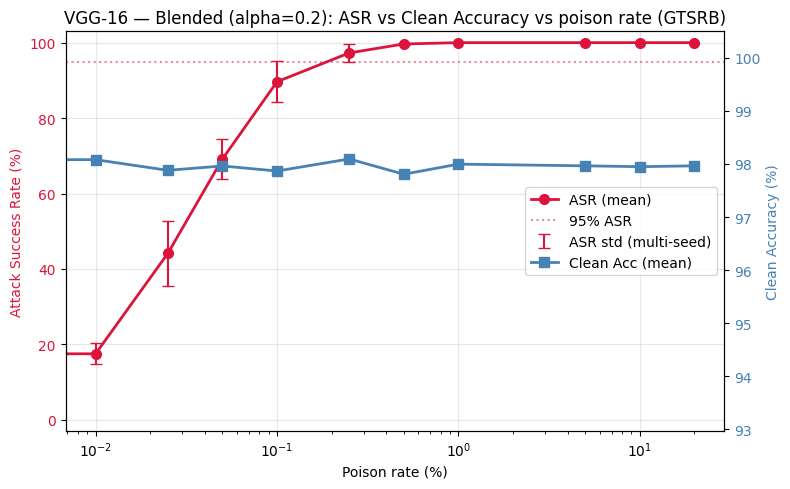

Saved vgg16_blended_gtsrb_rate_sweep.png
HEADLINE (A): Blended (alpha=0.2) achieves 97.3% mean ASR at just 0.25% poisoning (-0.13 pp clean cost) on VGG-16 (GTSRB).
Control — mean ASR at 0% poisoning: 0.31% (should be near-chance).


In [11]:
rates_pct   = [r * 100 for r in ACTIVE_RATES]
ca_pct      = [mean_ca(r) * 100 for r in ACTIVE_RATES]
asr_pct     = [mean_asr(r) * 100 for r in ACTIVE_RATES]
asr_std_pct = [std_asr(r) * 100 for r in ACTIVE_RATES]

fig, ax1 = plt.subplots(figsize=(8, 5))
color_asr, color_ca = 'crimson', 'steelblue'
ax1.plot(rates_pct, asr_pct, 'o-', color=color_asr, linewidth=2, markersize=7, label='ASR (mean)')
_multi = [i for i, r in enumerate(ACTIVE_RATES) if len(results_A[r]) > 1]
if _multi:
    ax1.errorbar([rates_pct[i] for i in _multi], [asr_pct[i] for i in _multi],
                 yerr=[asr_std_pct[i] for i in _multi], fmt='none', ecolor=color_asr,
                 capsize=4, elinewidth=1.5, label='ASR std (multi-seed)')
ax1.set_xscale('log')
ax1.set_xlabel('Poison rate (%)')
ax1.set_ylabel('Attack Success Rate (%)', color=color_asr)
ax1.tick_params(axis='y', labelcolor=color_asr)
ax1.set_ylim(-3, 103)
ax1.axhline(95, color=color_asr, linestyle=':', alpha=0.5, label='95% ASR')
ax2 = ax1.twinx()
ax2.plot(rates_pct, ca_pct, 's-', color=color_ca, linewidth=2, markersize=7, label='Clean Acc (mean)')
ax2.set_ylabel('Clean Accuracy (%)', color=color_ca)
ax2.tick_params(axis='y', labelcolor=color_ca)
_lo = min(ca_pct) - 2
ax2.set_ylim(min(_lo, baseline_ca*100 - 5), 100.5)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title(f'{MODEL_TITLE} — Blended (alpha={BLEND_ALPHA}): ASR vs Clean Accuracy vs poison rate ({DS_TITLE})')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_blended_{DS_SHORT}_rate_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {MODEL_NAME}_blended_{DS_SHORT}_rate_sweep.png')

# Headline: min poison rate for >=95% mean ASR at alpha=BLEND_ALPHA (clean-acc drop < 2pp).
ASR_TARGET, CA_DROP_MAX = 0.95, 0.02
qualifying = [r for r in ACTIVE_RATES if r != 0.0
              and mean_asr(r) >= ASR_TARGET and (baseline_ca - mean_ca(r)) < CA_DROP_MAX]
if qualifying:
    min_rate_A = min(qualifying)
    headline_A = (f'Blended (alpha={BLEND_ALPHA}) achieves {mean_asr(min_rate_A)*100:.1f}% mean ASR at just '
                  f'{rate_label(min_rate_A)} poisoning ({(baseline_ca-mean_ca(min_rate_A))*100:+.2f} pp clean cost) '
                  f'on {MODEL_TITLE} ({DS_TITLE}).')
else:
    min_rate_A = None
    pool = [(mean_asr(r), r) for r in ACTIVE_RATES if r != 0.0]
    top_asr, top_rate = max(pool)
    headline_A = (f'No rate hit >=95% mean ASR within <2pp clean drop at alpha={BLEND_ALPHA} on '
                  f'{MODEL_TITLE} ({DS_TITLE}); best {top_asr*100:.1f}% at {rate_label(top_rate)}.')
print('HEADLINE (A):', headline_A)
print(f'Control — mean ASR at 0% poisoning: {mean_asr(0.0)*100:.2f}% (should be near-chance).')

## Perceptual metrics setup (PSNR / SSIM / LPIPS)
Reused verbatim from the BadNets notebooks — same libs, same thresholds (PSNR > 30, SSIM > 0.95, LPIPS < 0.1), same `METRIC_N`. Computed in `[0,1]` pixel space between clean and blended images over a fixed `METRIC_N`-image sample (trigger perceptibility, measured over the sample exactly as BadNets did — not fooled-conditioned).

In [12]:
import subprocess, sys, math
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lpips', 'scikit-image', '-q'], check=True)
import lpips
from skimage.metrics import structural_similarity as ssim_fn

METRIC_N = 500   # number of test images to measure over (same as BadNets)
lpips_fn = lpips.LPIPS(net='alex').to(device)

def _psnr01(a, b):
    mse = ((a - b) ** 2).mean()
    return 10 * math.log10(1.0 / mse) if mse > 0 else float('inf')

_metric_rng = random.Random(SEED)
metric_idx = _metric_rng.sample(range(len(test_split)), min(METRIC_N, len(test_split)))

def perceptual_at_alpha(alpha):
    """Mean PSNR/SSIM/LPIPS between clean and blended@alpha over the fixed metric sample."""
    psnrs, ssims, lpips_vals = [], [], []
    with torch.no_grad():
        for idx in metric_idx:
            img01, _ = test_split[idx]              # [0,1] CHW
            trig01 = apply_trigger(img01, alpha)
            o = img01.permute(1, 2, 0).numpy()
            a = trig01.permute(1, 2, 0).numpy()
            psnrs.append(_psnr01(o, a))
            ssims.append(ssim_fn(o, a, channel_axis=2, data_range=1.0))
            o11 = (img01.unsqueeze(0).to(device)  * 2 - 1)   # LPIPS expects [-1,1]
            a11 = (trig01.unsqueeze(0).to(device) * 2 - 1)
            lpips_vals.append(lpips_fn(o11, a11).item())
    finite = [p for p in psnrs if math.isfinite(p)]
    return float(np.mean(finite)), float(np.mean(ssims)), float(np.mean(lpips_vals))
print(f'Perceptual setup ready (METRIC_N={METRIC_N}).')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lpips\weights\v0.1\alex.pth
Perceptual setup ready (METRIC_N=500).


c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Block B — alpha sweep at fixed rate = `RATE_FOR_ALPHA_SWEEP`
Iterate `BLEND_ALPHAS` with the poison rate pinned, **single seed** (`SEED`) for v1. For each alpha: train-or-reuse, compute CA + ASR, and the PSNR/SSIM/LPIPS of the blended images.

> **Note:** the low-alpha end (0.02, 0.05) is the marginal regime where — per our BadNets seed-variance finding — a single seed may be unreliable. Multi-seeding the low-alpha end is a known **v1.5** fix if Block B looks noisy.

In [13]:
RATE_B = RATE_FOR_ALPHA_SWEEP
alpha_checkpoints = {}
for alpha in BLEND_ALPHAS:
    existing = resolve_ckpt(alpha, RATE_B, SEED)
    if os.path.exists(existing):
        print(f'\n===== B a{alpha} p={RATE_B*100:.3g}% s{SEED} — exists, skipping ({existing}) =====')
        alpha_checkpoints[alpha] = existing
        continue
    print(f'\n===== Training B a{alpha} p={RATE_B*100:.3g}% s{SEED} =====')
    alpha_checkpoints[alpha] = train_one(RATE_B, alpha, SEED)
print('\nBlock B trainings done:', len(alpha_checkpoints), 'checkpoints')


===== Training B a0.0025 p=5% s42 =====
Poisoned 1568 / 31368 training images (5%) at alpha=0.0025
  [a0.0025 p=5.000% s42] Epoch 01/20 | Train Loss 0.6636 Acc 0.8242 | Val(clean) Loss 0.1058 Acc 0.9769 *** saved
  [a0.0025 p=5.000% s42] Epoch 02/20 | Train Loss 0.3087 Acc 0.9281 | Val(clean) Loss 0.0643 Acc 0.9898 *** saved
  [a0.0025 p=5.000% s42] Epoch 03/20 | Train Loss 0.2576 Acc 0.9393 | Val(clean) Loss 0.0507 Acc 0.9912 *** saved
  [a0.0025 p=5.000% s42] Epoch 04/20 | Train Loss 0.2270 Acc 0.9426 | Val(clean) Loss 0.0370 Acc 0.9945 *** saved
  [a0.0025 p=5.000% s42] Epoch 05/20 | Train Loss 0.2010 Acc 0.9457 | Val(clean) Loss 0.0529 Acc 0.9906
  [a0.0025 p=5.000% s42] Epoch 06/20 | Train Loss 0.1777 Acc 0.9487 | Val(clean) Loss 0.0386 Acc 0.9916
  [a0.0025 p=5.000% s42] Epoch 07/20 | Train Loss 0.1475 Acc 0.9552 | Val(clean) Loss 0.0573 Acc 0.9857
  [a0.0025 p=5.000% s42] Epoch 08/20 | Train Loss 0.1103 Acc 0.9647 | Val(clean) Loss 0.0375 Acc 0.9895
  [a0.0025 p=5.000% s42] Epo

In [14]:
if 'alpha_checkpoints' not in dir():
    alpha_checkpoints = {a: resolve_ckpt(a, RATE_FOR_ALPHA_SWEEP, SEED) for a in BLEND_ALPHAS}

alpha_results = {}   # alpha -> {clean_acc, asr, psnr, ssim, lpips}
print(f'{MODEL_TITLE} — Blended alpha sweep at rate={RATE_FOR_ALPHA_SWEEP*100:.3g}% on {DS_TITLE}')
print('alpha  | Clean Acc | ASR     | PSNR(dB) | SSIM   | LPIPS   (PSNR>30 SSIM>0.95 LPIPS<0.1 = imperceptible)')
print('-' * 92)
for alpha in BLEND_ALPHAS:
    ca, asr = evaluate_checkpoint(alpha_checkpoints[alpha], alpha)
    psnr, ssim, lp = perceptual_at_alpha(alpha)
    alpha_results[alpha] = {'clean_acc': ca, 'asr': asr, 'psnr': psnr, 'ssim': ssim, 'lpips': lp}
    print(f'{alpha:<6} | {ca*100:7.2f}% | {asr*100:6.2f}% | {psnr:7.2f}  | {ssim:.4f} | {lp:.4f}')

VGG-16 — Blended alpha sweep at rate=5% on GTSRB
alpha  | Clean Acc | ASR     | PSNR(dB) | SSIM   | LPIPS   (PSNR>30 SSIM>0.95 LPIPS<0.1 = imperceptible)
--------------------------------------------------------------------------------------------
0.0025 |   96.45% |   0.30% |   59.38  | 0.9996 | 0.0001
0.005  |   97.20% |  25.23% |   53.36  | 0.9983 | 0.0004
0.01   |   97.74% |  77.57% |   47.34  | 0.9933 | 0.0048
0.02   |   98.08% |  98.81% |   41.32  | 0.9739 | 0.0430
0.05   |   98.15% |  99.92% |   33.36  | 0.8609 | 0.2502
0.1    |   97.75% | 100.00% |   27.34  | 0.6255 | 0.5424
0.15   |   97.64% |  99.99% |   23.82  | 0.4450 | 0.7325
0.2    |   97.97% | 100.00% |   21.32  | 0.3247 | 0.8683
0.3    |   97.96% | 100.00% |   17.79  | 0.1876 | 1.0691


### Block B — the "money plot": stealth vs potency
x = alpha; LEFT y = ASR (potency); RIGHT y = SSIM & LPIPS (stealth). As alpha rises, ASR climbs while SSIM falls / LPIPS rises (the image looks less clean). Saved as `vgg16_blended_gtsrb_alpha_sweep.png`.

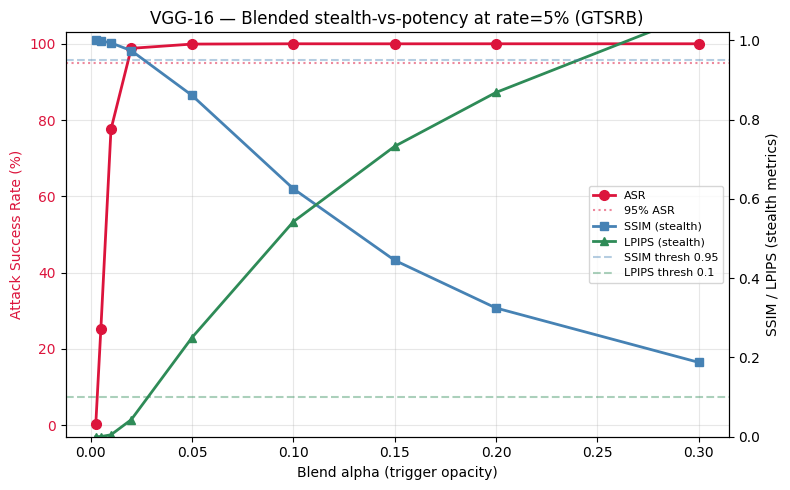

Saved vgg16_blended_gtsrb_alpha_sweep.png


In [15]:
alphas  = list(BLEND_ALPHAS)
asr_b   = [alpha_results[a]['asr'] * 100 for a in alphas]
ssim_b  = [alpha_results[a]['ssim'] for a in alphas]
lpips_b = [alpha_results[a]['lpips'] for a in alphas]

fig, ax1 = plt.subplots(figsize=(8, 5))
c_asr, c_ssim, c_lpips = 'crimson', 'steelblue', 'seagreen'
ax1.plot(alphas, asr_b, 'o-', color=c_asr, linewidth=2, markersize=7, label='ASR')
ax1.axhline(95, color=c_asr, linestyle=':', alpha=0.5, label='95% ASR')
ax1.set_xlabel('Blend alpha (trigger opacity)')
ax1.set_ylabel('Attack Success Rate (%)', color=c_asr)
ax1.tick_params(axis='y', labelcolor=c_asr)
ax1.set_ylim(-3, 103)
ax2 = ax1.twinx()
ax2.plot(alphas, ssim_b,  's-', color=c_ssim,  linewidth=2, markersize=6, label='SSIM (stealth)')
ax2.plot(alphas, lpips_b, '^-', color=c_lpips, linewidth=2, markersize=6, label='LPIPS (stealth)')
ax2.axhline(0.95, color=c_ssim,  linestyle='--', alpha=0.4, label='SSIM thresh 0.95')
ax2.axhline(0.10, color=c_lpips, linestyle='--', alpha=0.4, label='LPIPS thresh 0.1')
ax2.set_ylabel('SSIM / LPIPS (stealth metrics)')
ax2.set_ylim(0, 1.02)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)
plt.title(f'{MODEL_TITLE} — Blended stealth-vs-potency at rate={RATE_FOR_ALPHA_SWEEP*100:.3g}% ({DS_TITLE})')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_blended_{DS_SHORT}_alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {MODEL_NAME}_blended_{DS_SHORT}_alpha_sweep.png')

## Part 7 — Perceptual framing (why Blended needs SSIM/LPIPS)
BadNets' **localized 24px patch FAILED PSNR but PASSED SSIM/LPIPS**: those global, spatially-averaged metrics ignore a tiny localized patch (~1% of a 224×224 image), so only the per-pixel PSNR flagged it. **Blended is a WHOLE-IMAGE perturbation**, so SSIM and LPIPS are now the **appropriate** stealth metrics — the same regime as the evasion attacks (FGSM/PGD/AutoAttack), where the perturbation also spans the whole image. This contrast is exactly why the benchmark needs **both** a localized backdoor (BadNets, Gu et al. 2017) and a global one (Blended, Chen et al. 2017). Stealthier triggers (WaNet) are future work.

## Visualization — clean vs blended across ALL alphas
Rows = sample non-target test images. Columns = the clean image, then the image blended at **every alpha in `BLEND_ALPHAS`**. Each blended cell is titled with its alpha and the prediction of that alpha's **Block-B backdoor model** (trained at rate=`RATE_FOR_ALPHA_SWEEP`); red `*` = flipped to the target class. This shows stealth (appearance) and potency (prediction flips) ramping together with alpha — the visual companion to the money plot.

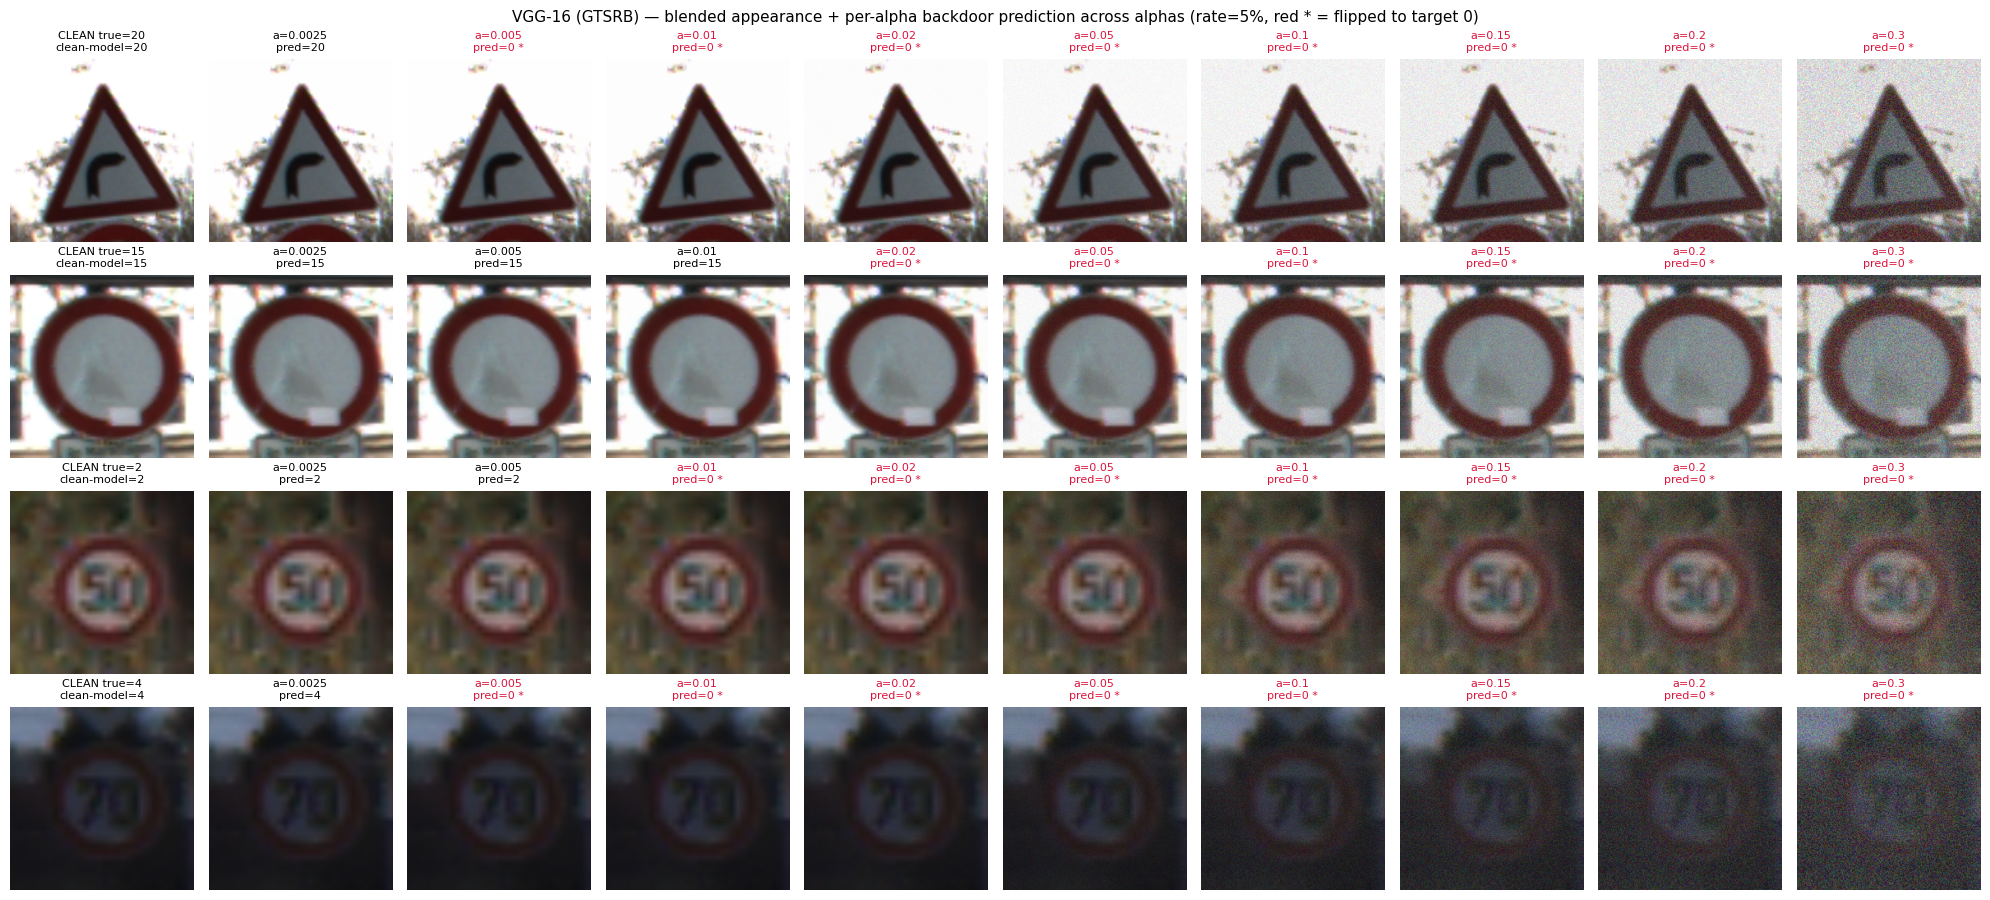

In [16]:
# Clean control = Block A's 0%-poison model. Per-alpha backdoor models = Block B checkpoints
# (each trained at rate=RATE_FOR_ALPHA_SWEEP), so the prediction shown per column matches the
# alpha used to blend that column.
clean_model = build_model(pretrained=False)
clean_model.load_state_dict(torch.load(checkpoints_A[(0.0, SEED)], map_location=device)); clean_model.eval()
alpha_models = {}
for a in BLEND_ALPHAS:
    m = build_model(pretrained=False)
    m.load_state_dict(torch.load(alpha_checkpoints[a], map_location=device)); m.eval()
    alpha_models[a] = m

rng = random.Random(SEED)
cand = [i for i in range(len(test_split)) if test_split[i][1] != TARGET_LABEL]
show_idx = rng.sample(cand, 4)

ncols = 1 + len(BLEND_ALPHAS)
fig, axes = plt.subplots(len(show_idx), ncols, figsize=(2.0 * ncols, 2.3 * len(show_idx)))
with torch.no_grad():
    for row, idx in enumerate(show_idx):
        img01, true_label = test_split[idx]
        # Clean column: clean-control prediction on the un-triggered image.
        cp = clean_model(normalize(img01).unsqueeze(0).to(device)).argmax(1).item()
        ax = axes[row, 0]
        ax.imshow(img01.permute(1, 2, 0).numpy())
        ax.set_title(f'CLEAN true={true_label}\nclean-model={cp}', fontsize=8)
        ax.axis('off')
        # One column per alpha: blended image + that alpha's backdoor-model prediction.
        for col, a in enumerate(BLEND_ALPHAS, start=1):
            trig01 = apply_trigger(img01, a)
            pred = alpha_models[a](normalize(trig01).unsqueeze(0).to(device)).argmax(1).item()
            flipped = pred == TARGET_LABEL
            ax = axes[row, col]
            ax.imshow(trig01.permute(1, 2, 0).numpy())
            ax.set_title(f'a={a}\npred={pred}' + (' *' if flipped else ''),
                         fontsize=8, color=('crimson' if flipped else 'black'))
            ax.axis('off')
plt.suptitle(f'{MODEL_TITLE} ({DS_TITLE}) — blended appearance + per-alpha backdoor prediction across alphas '
             f'(rate={RATE_FOR_ALPHA_SWEEP*100:.3g}%, red * = flipped to target {TARGET_LABEL})', fontsize=11)
plt.tight_layout()
plt.show()

## Block C — focused 2-D (alpha × poison-rate) grid AROUND THE FLOOR
Blocks A and B are independent 1-D sweeps; Block C is the small 2-D grid over the transition **corner** where ASR actually varies. ASR saturates to ~100% above alpha≈0.02 and above rate≈0.5%, so that cross-product is already known — this grid deliberately covers only the floor. Cells are **seed-averaged in the noisy region** (`rate ≤ LOW_RATE_THRESHOLD` OR `alpha ≤ 0.01`) and single-seed elsewhere. Already-trained checkpoints (incl. Block B's alpha-row at rate=5%) are **reused, not retrained** — keeping `alpha_train == alpha_test` (v1).

In [17]:
GRID_ALPHAS = [0.005, 0.01, 0.02, 0.05]
GRID_RATES  = [0.001, 0.0025, 0.005, 0.01, 0.05]
# Rationale: ASR saturates ~100% above alpha=0.02 and above rate~0.5%, so the cross-product
# there is already known. This grid covers the transition CORNER where ASR varies — the floor.

def seeds_for_grid(alpha, rate):
    # Extend the noisy-region multi-seed rule to BOTH axes: 3 seeds in the marginal region
    # (rate <= LOW_RATE_THRESHOLD OR alpha <= 0.01), single seed (42) in the near-saturated rest.
    return SEEDS if (rate <= LOW_RATE_THRESHOLD or alpha <= 0.01) else [SEED]

# Dry-run plan: show REUSE vs TRAIN per (alpha, rate, seed) BEFORE spending any GPU.
_n_reuse = _n_train = 0
print('Block C grid plan (REUSE = checkpoint on disk, TRAIN = will train):')
for alpha in GRID_ALPHAS:
    for rate in GRID_RATES:
        for seed in seeds_for_grid(alpha, rate):
            existing = resolve_ckpt(alpha, rate, seed)
            if os.path.exists(existing):
                _n_reuse += 1
                print(f'  REUSE a{alpha} p={rate*100:.4g}% s{seed}  ({existing})')
            else:
                _n_train += 1
                print(f'  TRAIN a{alpha} p={rate*100:.4g}% s{seed}')
_n_runs = sum(len(seeds_for_grid(a, r)) for a in GRID_ALPHAS for r in GRID_RATES)
print(f'\nBlock C: {len(GRID_ALPHAS)}x{len(GRID_RATES)} grid, {_n_runs} (alpha,rate,seed) runs '
      f'-> {_n_reuse} REUSE, {_n_train} TRAIN. (Review before running the next cell.)')

Block C grid plan (REUSE = checkpoint on disk, TRAIN = will train):
  TRAIN a0.005 p=0.1% s42
  TRAIN a0.005 p=0.1% s123
  TRAIN a0.005 p=0.1% s7
  TRAIN a0.005 p=0.25% s42
  TRAIN a0.005 p=0.25% s123
  TRAIN a0.005 p=0.25% s7
  TRAIN a0.005 p=0.5% s42
  TRAIN a0.005 p=0.5% s123
  TRAIN a0.005 p=0.5% s7
  TRAIN a0.005 p=1% s42
  TRAIN a0.005 p=1% s123
  TRAIN a0.005 p=1% s7
  REUSE a0.005 p=5% s42  (models\blended_vgg16_a0.005_p0.05_s42.pth)
  TRAIN a0.005 p=5% s123
  TRAIN a0.005 p=5% s7
  TRAIN a0.01 p=0.1% s42
  TRAIN a0.01 p=0.1% s123
  TRAIN a0.01 p=0.1% s7
  TRAIN a0.01 p=0.25% s42
  TRAIN a0.01 p=0.25% s123
  TRAIN a0.01 p=0.25% s7
  TRAIN a0.01 p=0.5% s42
  TRAIN a0.01 p=0.5% s123
  TRAIN a0.01 p=0.5% s7
  TRAIN a0.01 p=1% s42
  TRAIN a0.01 p=1% s123
  TRAIN a0.01 p=1% s7
  REUSE a0.01 p=5% s42  (models\blended_vgg16_a0.01_p0.05_s42.pth)
  TRAIN a0.01 p=5% s123
  TRAIN a0.01 p=5% s7
  TRAIN a0.02 p=0.1% s42
  TRAIN a0.02 p=0.1% s123
  TRAIN a0.02 p=0.1% s7
  TRAIN a0.02 p=0.25%

In [18]:
# Train-or-reuse every grid cell, then evaluate. alpha_train == alpha_test (v1 convention).
grid_results = {}   # (alpha, rate) -> {asr_mean, asr_std, ca_mean, n_seeds}
_done_reuse = _done_train = 0
for alpha in GRID_ALPHAS:
    for rate in GRID_RATES:
        seeds = seeds_for_grid(alpha, rate)
        asrs, cas = [], []
        for seed in seeds:
            existing = resolve_ckpt(alpha, rate, seed)
            if os.path.exists(existing):
                ck = existing; _done_reuse += 1
            else:
                print(f'  TRAIN a{alpha} p={rate*100:.4g}% s{seed}')
                ck = train_one(rate, alpha, seed); _done_train += 1
            ca, asr = evaluate_checkpoint(ck, alpha)
            asrs.append(asr); cas.append(ca)
        grid_results[(alpha, rate)] = {'asr_mean': float(np.mean(asrs)), 'asr_std': float(np.std(asrs)),
                                       'ca_mean': float(np.mean(cas)), 'n_seeds': len(seeds)}
        g = grid_results[(alpha, rate)]
        print(f'  a{alpha} p={rate*100:.4g}%  ASR={g["asr_mean"]*100:5.1f}% +/- {g["asr_std"]*100:4.1f}  '
              f'CA={g["ca_mean"]*100:5.2f}%  (n_seeds={g["n_seeds"]})')
print(f'\nBlock C eval done: {_done_reuse} reused, {_done_train} trained.')

  TRAIN a0.005 p=0.1% s42
Poisoned 31 / 31368 training images (0.1%) at alpha=0.005
  [a0.005 p=0.100% s42] Epoch 01/20 | Train Loss 0.3906 Acc 0.8855 | Val(clean) Loss 0.0646 Acc 0.9802 *** saved
  [a0.005 p=0.100% s42] Epoch 02/20 | Train Loss 0.0713 Acc 0.9815 | Val(clean) Loss 0.0344 Acc 0.9888 *** saved
  [a0.005 p=0.100% s42] Epoch 03/20 | Train Loss 0.0406 Acc 0.9905 | Val(clean) Loss 0.0201 Acc 0.9950 *** saved
  [a0.005 p=0.100% s42] Epoch 04/20 | Train Loss 0.0286 Acc 0.9933 | Val(clean) Loss 0.0275 Acc 0.9927
  [a0.005 p=0.100% s42] Epoch 05/20 | Train Loss 0.0227 Acc 0.9943 | Val(clean) Loss 0.0217 Acc 0.9943
  [a0.005 p=0.100% s42] Epoch 06/20 | Train Loss 0.0199 Acc 0.9954 | Val(clean) Loss 0.0159 Acc 0.9954 *** saved
  [a0.005 p=0.100% s42] Epoch 07/20 | Train Loss 0.0148 Acc 0.9957 | Val(clean) Loss 0.0096 Acc 0.9972 *** saved
  [a0.005 p=0.100% s42] Epoch 08/20 | Train Loss 0.0100 Acc 0.9977 | Val(clean) Loss 0.0180 Acc 0.9962
  [a0.005 p=0.100% s42] Epoch 09/20 | Trai

### Block C — ASR floor heatmap
x = poison rate (log), y = alpha (log), color = mean ASR. Each cell annotated with its mean ASR (±std for multi-seed cells). Saved as `vgg16_blended_gtsrb_floor_heatmap.png`.

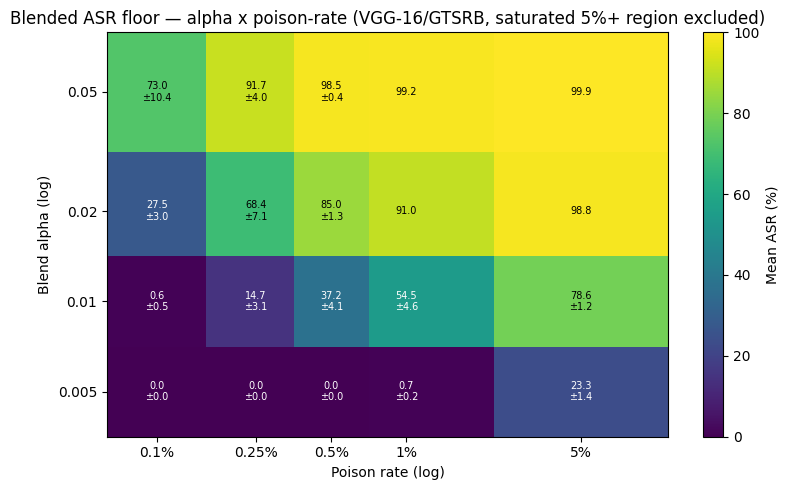

Saved vgg16_blended_gtsrb_floor_heatmap.png


In [19]:
# ASR heatmap on log-log axes; cells annotated with mean ASR (+/- std if multi-seed).
M = np.array([[grid_results[(a, r)]['asr_mean'] * 100 for r in GRID_RATES] for a in GRID_ALPHAS])

def _log_edges(vals):
    lv = np.log10(np.array(vals, float))
    mid = (lv[:-1] + lv[1:]) / 2
    return 10 ** np.concatenate([[lv[0] - (mid[0] - lv[0])], mid, [lv[-1] + (lv[-1] - mid[-1])]])

xe, ye = _log_edges(GRID_RATES), _log_edges(GRID_ALPHAS)
fig, ax = plt.subplots(figsize=(8, 5))
pcm = ax.pcolormesh(xe, ye, M, cmap='viridis', vmin=0, vmax=100, shading='flat')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xticks(GRID_RATES); ax.set_xticklabels([f'{r*100:.4g}%' for r in GRID_RATES])
ax.set_yticks(GRID_ALPHAS); ax.set_yticklabels([str(a) for a in GRID_ALPHAS])
ax.minorticks_off()
for a in GRID_ALPHAS:
    for r in GRID_RATES:
        g = grid_results[(a, r)]
        txt = f'{g["asr_mean"]*100:.1f}'
        if g['n_seeds'] > 1: txt += f'\n±{g["asr_std"]*100:.1f}'
        ax.text(r, a, txt, ha='center', va='center', fontsize=7,
                color=('white' if g['asr_mean']*100 < 55 else 'black'))
ax.set_xlabel('Poison rate (log)'); ax.set_ylabel('Blend alpha (log)')
fig.colorbar(pcm, ax=ax, label='Mean ASR (%)')
plt.title(f'Blended ASR floor — alpha x poison-rate ({MODEL_TITLE}/{DS_TITLE}, saturated 5%+ region excluded)')
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_blended_{DS_SHORT}_floor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {MODEL_NAME}_blended_{DS_SHORT}_floor_heatmap.png')

### Block C — stealthy-AND-potent heatmap
Same mean-ASR color, but cells whose trigger is **imperceptible (SSIM > 0.95)** are circled. SSIM depends only on alpha (constant down each alpha row), computed via the existing `perceptual_at_alpha`. The circled high-ASR cells are the region that is simultaneously imperceptible and reliable. Saved as `vgg16_blended_gtsrb_floor_stealth_heatmap.png`.

SSIM by alpha (constant across rate): {0.005: 0.9983, 0.01: 0.9933, 0.02: 0.9739, 0.05: 0.8609}


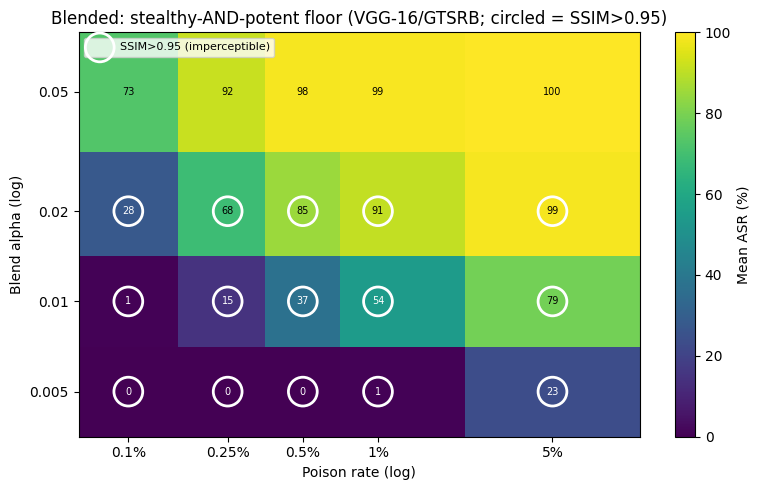

Saved vgg16_blended_gtsrb_floor_stealth_heatmap.png


In [20]:
# SSIM depends only on alpha -> compute once per alpha row (reuse perceptual_at_alpha).
ssim_by_alpha = {a: perceptual_at_alpha(a)[1] for a in GRID_ALPHAS}
print('SSIM by alpha (constant across rate):', {a: round(s, 4) for a, s in ssim_by_alpha.items()})

fig, ax = plt.subplots(figsize=(8, 5))
pcm = ax.pcolormesh(xe, ye, M, cmap='viridis', vmin=0, vmax=100, shading='flat')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xticks(GRID_RATES); ax.set_xticklabels([f'{r*100:.4g}%' for r in GRID_RATES])
ax.set_yticks(GRID_ALPHAS); ax.set_yticklabels([str(a) for a in GRID_ALPHAS])
ax.minorticks_off()
_stealthy = [(a, r) for a in GRID_ALPHAS for r in GRID_RATES if ssim_by_alpha[a] > 0.95]
if _stealthy:
    ax.scatter([r for a, r in _stealthy], [a for a, r in _stealthy], s=430, marker='o',
               facecolors='none', edgecolors='white', linewidths=2.0, label='SSIM>0.95 (imperceptible)')
    ax.legend(loc='upper left', fontsize=8)
for a in GRID_ALPHAS:
    for r in GRID_RATES:
        g = grid_results[(a, r)]
        ax.text(r, a, f'{g["asr_mean"]*100:.0f}', ha='center', va='center', fontsize=7,
                color=('white' if g['asr_mean']*100 < 55 else 'black'))
ax.set_xlabel('Poison rate (log)'); ax.set_ylabel('Blend alpha (log)')
fig.colorbar(pcm, ax=ax, label='Mean ASR (%)')
plt.title(f'Blended: stealthy-AND-potent floor ({MODEL_TITLE}/{DS_TITLE}; circled = SSIM>0.95)')
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_blended_{DS_SHORT}_floor_stealth_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {MODEL_NAME}_blended_{DS_SHORT}_floor_stealth_heatmap.png')

## Part 8 — Summary + JSON dump
Dumps Block A (rate sweep), Block B (alpha sweep) and Block C (floor grid) plus full config to `blended_vgg16_gtsrb.json` for cross-model aggregation.

In [21]:
print('=' * 80)
print('HEADLINE (A, rate floor @ alpha={}):'.format(BLEND_ALPHA), headline_A)
# Block B readout: smallest alpha reaching >=95% ASR at the fixed rate.
alpha_hits = [a for a in BLEND_ALPHAS if alpha_results[a]['asr'] >= 0.95]
min_alpha_95 = min(alpha_hits) if alpha_hits else None
if min_alpha_95 is not None:
    print(f'HEADLINE (B, alpha floor @ rate={RATE_FOR_ALPHA_SWEEP*100:.3g}%): >=95% ASR from alpha={min_alpha_95} '
          f'(SSIM={alpha_results[min_alpha_95]["ssim"]:.3f}, LPIPS={alpha_results[min_alpha_95]["lpips"]:.3f}).')
else:
    print(f'HEADLINE (B): no alpha in {BLEND_ALPHAS} reached >=95% ASR at rate={RATE_FOR_ALPHA_SWEEP*100:.3g}%.')
print('=' * 80)

out = {
    'model': MODEL_NAME,
    'dataset': DS_SHORT,
    'attack': 'blended',
    'reference': 'Chen et al. 2017 (Targeted Backdoor Attacks via Data Poisoning)',
    'target_label': TARGET_LABEL,
    'trigger': {'type': 'blended seeded whole-image random-noise', 'trigger_seed': TRIGGER_SEED,
                'img_size': IMG_SIZE, 'blend': 'x_adv = (1-alpha)*x + alpha*k',
                'space': '[0,1] pixel space, applied before normalization',
                'alpha_train_eq_alpha_test': True},
    'num_epochs': NUM_EPOCHS, 'batch_size': BATCH_SIZE, 'num_classes': NUM_CLASSES,
    'seed': SEED, 'seeds': SEEDS, 'low_rate_threshold': LOW_RATE_THRESHOLD,
    'blend_alpha': BLEND_ALPHA, 'blend_alphas': list(BLEND_ALPHAS),
    'rate_for_alpha_sweep': RATE_FOR_ALPHA_SWEEP,
    'poison_rates_grid': list(POISON_RATES),
    'poison_rates': list(ACTIVE_RATES),
    # ── Block A: rate sweep at fixed alpha=BLEND_ALPHA ──
    'block_a': {
        'alpha': BLEND_ALPHA,
        'runs': {str(r): results_A[r] for r in ACTIVE_RATES},
        'clean_acc_mean': [mean_ca(r) for r in ACTIVE_RATES],
        'clean_acc_std':  [std_ca(r) for r in ACTIVE_RATES],
        'asr_mean': [mean_asr(r) for r in ACTIVE_RATES],
        'asr_std':  [std_asr(r) for r in ACTIVE_RATES],
        'clean_acc_drop_mean': [baseline_ca - mean_ca(r) for r in ACTIVE_RATES],
        'baseline_clean_acc': baseline_ca,
        'min_rate_95asr_2pp': min_rate_A,
        'headline': headline_A,
    },
    # ── Block B: alpha sweep at fixed rate=RATE_FOR_ALPHA_SWEEP (single seed) ──
    'block_b': {
        'rate': RATE_FOR_ALPHA_SWEEP,
        'alpha_results': {str(a): alpha_results[a] for a in BLEND_ALPHAS},
        'min_alpha_95asr': min_alpha_95,
    },
    # ── Block C: focused 2-D floor grid (None if Block C cells weren't run) ──
    'block_c': ({
        'grid_alphas': GRID_ALPHAS, 'grid_rates': GRID_RATES,
        'seeding_rule': 'multi-seed if rate<=LOW_RATE_THRESHOLD or alpha<=0.01, else seed 42',
        'grid_results': {f'a{a}_p{r}': grid_results[(a, r)] for a in GRID_ALPHAS for r in GRID_RATES},
    } if 'grid_results' in dir() else None),
}
json_path = f'blended_{MODEL_NAME}_{DS_SHORT}.json'
with open(json_path, 'w') as f:
    json.dump(out, f, indent=2)
print(f'Saved {json_path}')

HEADLINE (A, rate floor @ alpha=0.2): Blended (alpha=0.2) achieves 97.3% mean ASR at just 0.25% poisoning (-0.13 pp clean cost) on VGG-16 (GTSRB).
HEADLINE (B, alpha floor @ rate=5%): >=95% ASR from alpha=0.02 (SSIM=0.974, LPIPS=0.043).
Saved blended_vgg16_gtsrb.json
